<a href="https://colab.research.google.com/github/Dragnel25/timeseriesdoan/blob/main/notebooks_02_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bắt đầu tạo đặc trưng (Feature Engineering)...
Đã chia xong: Train (70%), Val (15%), Test (15%)
Đang huấn luyện XGBoost...

--- BẢNG KẾT QUẢ TRÊN TẬP TEST ---
Baseline (Lag 24h) | MAE: 925.08 | RMSE: 1220.39 | MAPE: 6.23%
XGBoost (Fourier)  | MAE: 160.85 | RMSE: 211.63 | MAPE: 1.09%


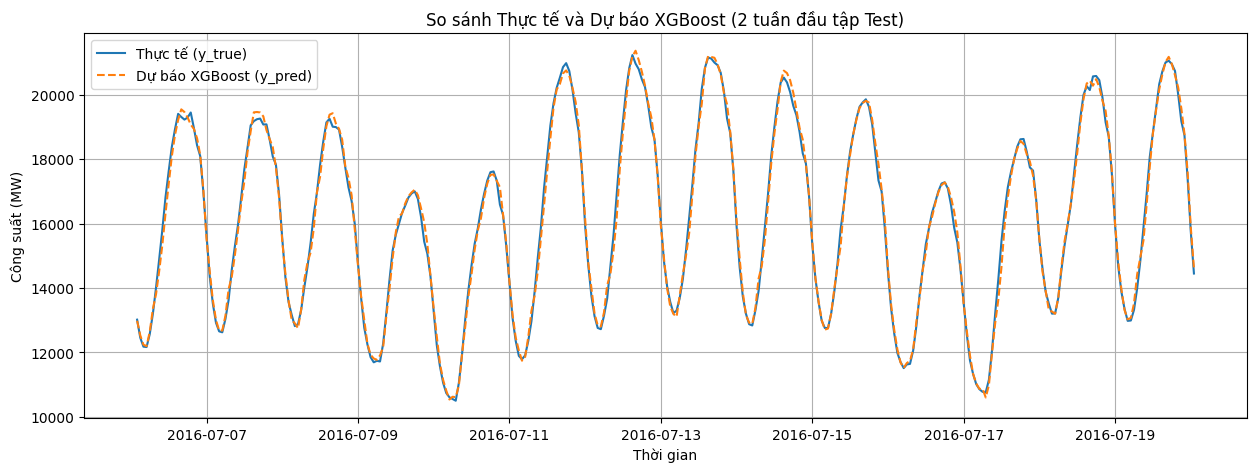

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# 1. ĐỌC DỮ LIỆU (Tương tự file 01)
url = "https://raw.githubusercontent.com/Dragnel25/timeseriesdoan/refs/heads/main/AEP_hourly.csv"
df = pd.read_csv(url)
df.columns = ['Datetime', 'Load']
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
# Handle duplicate timestamps by taking the mean of 'Load' for each unique timestamp
df = df.groupby(df.index).mean()
df = df.resample('h').interpolate(method='linear')

print("Bắt đầu tạo đặc trưng (Feature Engineering)...")

# 2. TẠO BIẾN THỜI GIAN VÀ MÙA VỤ
# Biến thời gian cơ bản
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Biến Fourier cho chu kỳ ngày (24h) và tuần (168h)
# Dùng cả sin và cos giúp mô hình học được cả biên độ và độ lệch pha
t = np.arange(len(df))
df['sin_daily'] = np.sin(2 * np.pi * t / 24)
df['cos_daily'] = np.cos(2 * np.pi * t / 24)
df['sin_weekly'] = np.sin(2 * np.pi * t / 168)
df['cos_weekly'] = np.cos(2 * np.pi * t / 168)

# Biến trễ (Lag features): Lấy giá trị của 1 giờ trước và 24 giờ trước
df['lag_1'] = df['Load'].shift(1)
df['lag_24'] = df['Load'].shift(24)

# Bỏ đi các dòng NaN do hàm shift tạo ra ở những giờ đầu tiên
df = df.dropna()

# 3. CHIA TẬP DỮ LIỆU (70% Train, 15% Validation, 15% Test)
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

# Tách features (X) và target (y)
features = [c for c in df.columns if c != 'Load']
X_train, y_train = train[features], train['Load']
X_val, y_val = val[features], val['Load']
X_test, y_test = test[features], test['Load']

# Chuẩn hóa dữ liệu (Standard Scaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Đã chia xong: Train (70%), Val (15%), Test (15%)")

# 4. HUẤN LUYỆN MÔ HÌNH
# Baseline Model (Naive: Dự báo bằng chính giá trị của 24h trước)
y_pred_baseline = test['lag_24']

# Mô hình học máy mùa vụ (XGBoost)
print("Đang huấn luyện XGBoost...")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 5. ĐÁNH GIÁ VÀ SO SÁNH
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

mae_base, rmse_base, mape_base = calculate_metrics(y_test, y_pred_baseline)
mae_xgb, rmse_xgb, mape_xgb = calculate_metrics(y_test, y_pred_xgb)

print("\n--- BẢNG KẾT QUẢ TRÊN TẬP TEST ---")
print(f"Baseline (Lag 24h) | MAE: {mae_base:.2f} | RMSE: {rmse_base:.2f} | MAPE: {mape_base:.2f}%")
print(f"XGBoost (Fourier)  | MAE: {mae_xgb:.2f} | RMSE: {rmse_xgb:.2f} | MAPE: {mape_xgb:.2f}%")

# 6. VẼ ĐỒ THỊ y_true vs y_pred
plt.figure(figsize=(15, 5))
# Chỉ cắt 2 tuần đầu của tập Test để biểu đồ không bị rối mắt
plot_len = 24 * 14
plt.plot(y_test.index[:plot_len], y_test.values[:plot_len], label='Thực tế (y_true)')
plt.plot(y_test.index[:plot_len], y_pred_xgb[:plot_len], label='Dự báo XGBoost (y_pred)', linestyle='--')
plt.title("So sánh Thực tế và Dự báo XGBoost (2 tuần đầu tập Test)")
plt.xlabel("Thời gian")
plt.ylabel("Công suất (MW)")
plt.legend()
plt.grid(True)
plt.show()